# Anomalies detection summary

#### statistical method
- statistical method --> z-score:
    - normalize data: $z = \frac{x - \mu}{\sigma}$ --> distance to the mean expressed in standard deviation
    - fix a threshold, es. 3 standard deviation
    - whatever is further away than the fixed threshold = anomaly  
$|z| > 3 \quad \Longleftrightarrow \quad \frac{|x-\mu|}{\sigma} > 3 \quad \Longleftrightarrow \quad |x-\mu| > 3\sigma$

#### KMeans + DBSCAN
- KMeans + DBSCAN:
    - KMeans:
        - for each point compute distance to closest centroids
        - sort the distances
        - plot the sorted distances --> on the left points closer to the centroids they belong to, on the right points further away from the centroids they belong to = anomalies
        - look for an elbow --> figure out the % of anomalies and compute the number of anomalies N
        - from the sorted distances save the last N distances = anomalies
        - in the plot flag the points having these distances as anomalies
    
    - DBSCAN:
        - already flags outliers / noise / anomalies as lable = -1
        - just plot as usual

#### LOF
- Local Outlier Factor LOF
    - basically identical to DBSCAN, it's density based
    - uses n_neighbours and **contamination**: expected fraction of outliers in the data --> if in doubt go for 0.05
    - returns labels: if labels == 1 the point is fine, if it's ==-1 than it's an outlier
    - **I HAVE NO CLUE HOW TO TUNE THE PARAMETERS**, some ideas might be:
        - Plot the sorted LOF scores **TO CHOOSE CONTAMINATION**:
            - LOF gives each point a “how weird are you” score.
            - Sort those scores
            - plot those scores --> **negative_outlier_factor_**
            - If you see a flat part then a sharp jump (“knee”), that jump is where “normal ends and weird begins”.
            - Set **contamination so you cut around that knee** (or just pick the cutoff score directly instead of using contamination).
        
        - Compare those curves for different n_neighbors **TO CHOOSE N_NEIGHBOURS**:
            - for different n_neighbours like = [10, 20, 35, 50] run the algorithm
            - get the **negative_outlier_factor_**
            - sort them
            - plot them
            - Pick the k where the curve shows the clearest separation (cleanest knee)

#### IsolationForest
- IsolationForest
    - it runs a lot of tree classifier in parallel which randomly select a feature and then randomly slect a split value --> normal data still stays in groups even after random splits, while anomalies get lonly fast = shorter tree length 
    - it's like a normal random forest but with also **contamination**
    - it returns labels, if label == 1 the point is fine, if label == -1 it's an anomaly

#### OneClassSVM
- Boundary based --> OneClassSVM
    - do it yourself

#### NN
- NN
    - it uses autoencoders
    - you pass in input X with dimension N to an encoder, which reduces the dimension on the input compressing it to K << N
    - then a decoder tries to reconstruct the original input $\hat{X}$
    - build the model, the optimizer, the loss function, the tensor dataset, the dataloader and fix the number of epochs
    - train the model:
        - iterate on epochs
        - iterate on batches
        - zero the optimizer gradients
        - do the forward pass of the NN model passing the input X to compute the reconstructed input $\hat{X}$
        - compute loss function
        - take a step with otpimizer
    - then we compute reconstruction error RE for each feature:
        - if the input is a continuous number we use MSE
        - if the input is binary we use binary cross entropy
    - higher RE == anomalies

---

# 3.5 Anomaly Detection on the MNIST Dataset
In this exercise, you will apply several anomaly-detection techniques to the MNIST dataset and evaluate their performance using standard anomaly-detection metrics. Unlike clustering, **anomaly detection relies on scores assigned by each model rather than direct label predictions**. Understanding how such scores are produced and how to evaluate them is essential for comparing different approaches.

1. Load the MNIST training set and flatten each image into a vector. For this exercise, treat a small subset of the digits as anomalies according to the following categories, consistent with the examples shown in class:  
- Point anomalies: select a small number of digits and add strong pixel noise (e.g. salt-and pepper noise). These images deviate sharply from typical handwritten digits.
- Noisy or low-quality digits: identify the digits with the highest reconstruction error from a simple autoencoder (as shown during the lecture). These samples are realistic but poorly represented by the underlying structure.
- Collective anomalies: create a small synthetic cluster by generating random 28 × 28 images with low variance (e.g. Gaussian blobs). These images form a coherent group but lie far from the manifold of real digits.

Build the final dataset and create:
$X \in \mathbb{R}^{N \times 784}, \qquad y \in \{0,1\}^{N} \;\; (0=\text{normal},\; 1=\text{anomaly})$


#### In poor words
Do anomaly detection on MNIST, but instead of “these are class 0/1/2/…” you’ll build a dataset where each image is either normal or anomaly, and models will output a weirdness score (not a clean label). Then you evaluate how good the scores are at ranking anomalies.

1.	Download MNIST training set.  
2.	Flatten images  
Each 28×28 image becomes a vector of 784 numbers (pixels).  
3.	Create your own anomalies (3 types):  

A) Point anomalies (few, very obvious)  
- Take a small number of normal digits.
- Add aggressive noise (salt-and-pepper: random black/white pixels).
- These become “WTF is this” images.

B) Bad-quality real digits (still MNIST, but crappy ones)
- Train a simple autoencoder on MNIST.
- Compute reconstruction error for each digit.
- Take the ones with the highest reconstruction error (autoencoder sucks at reconstructing them) → call those anomalies.

C) Collective anomalies (a fake mini-cluster)
- Generate synthetic 28×28 images that look nothing like digits but are similar to each other (low variance blobs).
- Add them as anomalies. They form a “group of weird things”.

4.	Build final dataset  
- Stack everything together into:
    - X: all images, flattened → shape N \times 784
	- y: labels → length N
	    - y=0 for normal
	    - y=1 for anomaly

# Salt and pepper noise
Salt-and-pepper noise, also known as impulse noise, is a form of noise sometimes seen on digital images. For black-and-white or grayscale images, it presents as sparsely occurring white and black pixels, giving the appearance of an image sprinkled with salt and pepper.

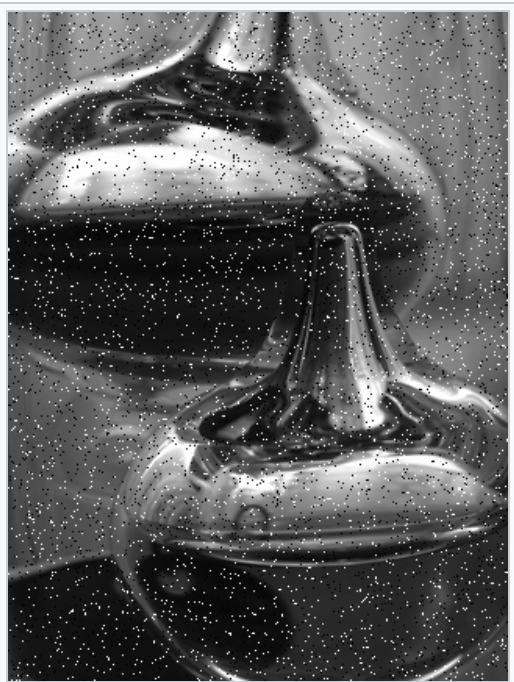

You take a normal image and randomly flip a small fraction of its pixels to extreme values:
- “pepper” = pixel becomes 0 (black)
- “salt” = pixel becomes max (white, 255 if using 0–255, or 1 if normalized)

You modify some existing pixel values in selected rows (images):
1.	Choose a subset of images you want to corrupt (these will become your “point anomalies”).  
2.	For each chosen image, choose a fraction of pixel positions to corrupt (e.g., 1%–10% depending on how “strong” you want it).  
3.	For those chosen pixels:  
- set half to 0 (pepper)
- set half to max (salt)

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import TensorDataset, DataLoader
import torch

In [ ]:
# already flattened

df = pd.read_csv('../../../Dataset/LAB8/mnist_train.csv')
df.drop(columns='label', inplace=True)

df.shape

In [ ]:
# add salt and pepper noise on a random subset rows and add the noise on a random subset of columns

# fix randomness
np.random.seed(42)

# list with labels so that we can keep track of the anomalies we're inserting
anomalies = np.zeros(shape=df.shape[0])

# pick 500 random row and random 50 col we'll add noise in
pepper_salt_row_idx = np.random.choice(a=df.shape[0], size=(500), replace=False)
anomalies[pepper_salt_row_idx] = 1

pepper_salt_col_idx = np.random.choice(a=df.shape[1], size=(50), replace=False)
pepper_col_idx = pepper_salt_col_idx[:50]
salt_col_idx = pepper_salt_col_idx[50:]

df.iloc[pepper_salt_row_idx, pepper_col_idx] = 0
df.iloc[pepper_salt_row_idx, salt_col_idx] = 1

> visualize the data after the insertion of point anomalies!

- imshow wants a 2D 28×28 grid
    - Pick one row (one image): that row is length 784.
    - Reshape it into (28, 28) so it becomes a 2D matrix.
    - imshow that 2D matrix with a grayscale colormap.

In [ ]:
# plot a subset of the changed data 
anomalous_data = df.iloc[pepper_salt_row_idx, :].values
rnd_anomalous_data_idx = np.random.choice(a=anomalous_data.shape[0], size=10, replace=False)

plt.figure(figsize=(15,15))
for plt_idx, anomaly in enumerate(anomalous_data[rnd_anomalous_data_idx]):
    anomaly = np.reshape(anomaly, shape=(28,28))
    
    plt.subplot(5,2, plt_idx+1)
    plt.imshow(X=anomaly, cmap='gray', vmin=0, vmax=1)
plt.tight_layout()
plt.show()

> **Noisy or low-quality digits**: identify the digits with the highest reconstruction error from a simple autoencoder (as shown during the lecture). These samples are realistic but poorly represented by the underlying structure.

In [ ]:
norm_arr = (df / 255).values
x = torch.tensor(norm_arr, dtype=torch.float32)

In [ ]:
# try to remake yourself the code seen in class
    # build class (the baseline is pre-made by pytorch)
    # build encoder and decoder in the __init__
    # encoder = sequential(linear + relu)
    # decoder = sequential(linear + relu + sigmoid)
    # recall the encoder and decoder in the forward method

class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64,10),
            nn.ReLU())
        
        self.decoder = nn.Sequential(
            nn.Linear(10, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256,784),
            nn.Sigmoid())


    def forward(self, x):
        x_encoded = self.encoder(x)
        x_reconstructed = self.decoder(x_encoded)
        return x_reconstructed


# normalize data, good for NN
norm_arr = (df / 255).values
x = torch.tensor(norm_arr, dtype=torch.float32)


# build NN model
# build Adam optimizer
# build tensor dataset
# build dataloader
# build loss function
# fix number of epochs (10)

NN = AutoEncoder()
optimizer = Adam(params=NN.parameters(), lr=1e-2)
dataset = TensorDataset(x)
data_loader = DataLoader(dataset=dataset, batch_size=256, shuffle=True)
loss_function = nn.MSELoss()
n_epochs = 10

# training loop:
    # iterate on the number of epochs
    # iterate on batches
    # zero the gradients of the optimizer
    # compute the forward pass, the reconstructed input
    # compute loss function + backward to update gradients or whatever
    # take a step with the optimizer
    # keep track of the loss per epoch hoping it reduces

for epoch in range(n_epochs):
    NN.train()
    loss_sum = 0
    for (x_batch,) in data_loader:
        optimizer.zero_grad()
        x_reconstructed = NN(x_batch)               # NN.forward(x_batch)
        loss = loss_function(x_reconstructed, x_batch)
        loss.backward()
        optimizer.step()

        loss_sum += loss.item()         # loss per batch
    
    loss_avg = loss_sum / len(data_loader)      # to compute avg loss divide it for the number of batches
    print(f"Epoch {epoch+1} --> avg loss {loss_avg:.6f}")

# no that we trained the model, let's actually compute the reconstructed inputs
# run the model in evaluation mode:
    # NN.eval() puts the model in evaluation mode
    # with torch.no_grad() --> tells PyTorch “don’t compute/store gradients”.
    # makes the forward pass faster and prevents gradient accumulation / memory waste + the optimizer won’t do anything because you won’t call backward() or optimizer.step().

NN.eval()
with torch.no_grad():
    x_reconstructed = NN(x)

# for each point (row) compute MSE: (sum per row(original input x - reconstructed input x_reconstructed)^2) / len(input)
x = torch.Tensor.numpy(x)
x_reconstructed = torch.Tensor.numpy(x_reconstructed)
print(x.shape, x_reconstructed.shape)


#### NN reminder pt2

##### Build the autoencoder (NN = AutoEncoder())
You build it now because training is going to repeatedly do:
1.	give it a batch of inputs x  
2.	get reconstructions $\hat{x}$  
3.	measure error  
4.	update weights  

> Does forward() run automatically?  
Yes. In PyTorch you normally call the model like a function:  
> NN(x_batch)  

That automatically triggers NN.forward(x_batch) under the hood.  
> So “forward pass” = “run the encoder + decoder to produce \hat{x}”.


##### Optimizer
Your model has weights. They start random. The optimizer is the thing that updates those weights after you compute gradients.

Loop logic:
- compute loss
- loss.backward() computes gradients \partial L/\partial W
- optimizer.step() uses those gradients to change the weights so loss goes down

##### TensorDataset
Say you have both data and the corresponding labels because it's supervised learning, then you pass the TensorDataset both of them:
- X: shape (10, 784) → 10 images
- y: shape (10,) → 10 labels (e.g., 0–9 or 0/1 anomaly)
> TensorDataset(X, y) --> Each item is (X[i], y[i]).

What TensorDataset(X, y) means
It creates a dataset where one item is a tuple:
- dataset[0] returns (X[0], y[0])
- dataset[1] returns (X[1], y[1])
- …

> So each index gives you (features, label).  
> That’s the whole point: the dataset “knows” that the two things belong together.  

> **TensorDataset(X, y) = “zip these together so index i gives me both the image and its label”.**

#### DataLoader
Now you wrap it:  
> DataLoader(dataset, batch_size=4, shuffle=False)

The DataLoader will group items into batches.  
Batch 1 uses indices [0,1,2,3] and returns:  
- x_batch = [X[0], X[1], X[2], X[3]] → shape (4, 784)
- y_batch = [y[0], y[1], y[2], y[3]] → shape (4,)
> give me a batch of inputs AND the matching batch of labels each time  
> for x_batch, y_batch in dl:  

**DataLoader(...) = “serve me those pairs in batches, optionally shuffled, so I can train efficiently”.**

- take the first point (row) of original input, the first point of the reconstructed input,
- subtract one point from another,
- square these value,
- sum these values (row)
- average them diving by how many elements there are per rows = number of columns
- each point has it's associated MSE (distance) to the reconstructed values by the NN
- sort these distances and the first values are the one with highest MSE, the worstly reconstructed
    - it means that it means that the autoencoder could not reproduce that image well, because that image doesn’t match the common patterns the model learned from the training data. So a high MSE suggests the sample is ‘weird’ compared to normal digits: it contains details/style/noise the model didn’t learn to represent, so it reconstructs it badly. Those high-MSE samples are good candidates for anomalies

In [ ]:
sqr_error = (x-x_reconstructed)**2
sum_sqr_error = np.sum(sqr_error, axis=1)
mean_sum_sqr_error = sum_sqr_error / x.shape[1]
sorted_mean_sum_sqr_error = np.sort(mean_sum_sqr_error)[::-1]

plt.figure(figsize=(8,6))
plt.plot(sorted_mean_sum_sqr_error)
plt.axvline(x=1800)
plt.xlabel('sorted points by MSE')
plt.ylabel('MSE score')
plt.title('find the worst reconstructed inputs')
plt.show()

worst_idxs = np.argsort(mean_sum_sqr_error)[::-1]
worst_idxs = np.random.choice(a=worst_idxs, size=10, replace=False)

plt.figure(figsize=(15,15))
for plt_idx, idx in enumerate(worst_idxs):
    anomaly_point = x[idx]

    plt.subplot(5,2, plt_idx+1)
    plt.imshow(x[idx].reshape(28,28), cmap='gray', vmin=0, vmax=1)
    plt.title(f"MSE={mean_sum_sqr_error[idx]:.3f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
# I'll flag those 1800 rows as anomalous == 1
worst_idxs = np.argsort(mean_sum_sqr_error)[::-1][1800]
anomalies[worst_idxs] = 1

> **Collective anomalies**: create a small synthetic cluster by generating random 28 ×28 images with low variance (e.g. Gaussian blobs). These images form a coherent group but lie far from the manifold of real digits.

### Strap on because this is hard as fuck ... I love this lab: short and very easy, ideal for application of stuff you've never seen before

You need to create “fake images”, new images, synthetic images not modify the existing ones. These synthetic images need to be created so they (1) look similar to each other (so they form a cluster), but (2) do not look like digits. “Gaussian blobs with low variance” is an easy way.  
- **Step 0**: pick how many fake images --> 200
- **Step 1**: build the 28×28 coordinate grid (the “pixel positions”). You want two 28×28 arrays, let's explain better.
“Each pixel is an object that has (x,y) inside it”. --> NO, it’s just a plain table of numbers. The only way the computer knows “where” a number is, is by its address (row index, column index). The two 28×28 tables are literally a way to write down those addresses as numbers so you can do math with them.

Full toy example: 3×3 image  
Pixels positions (x is column, y is row):  

*(y=0)*     (P0) (P1) (P2)  
*(y=1)*     (P3) **(P4)** (P5)  
*(y=2)*     (P6) (P7) (P8)  

            *(x=0) (x=1) (x=2)*  

Say the blob center is:
- cx = 1
- cy = 1

You want the squared distance of EVERY pixel from (1,1):  
$dist^2(y,x)=(x-1)^2+(y-1)^2$

Method 1: the loop  
- at (y=0,x=0): dist² = (0-1)² + (0-1)² = 1 + 1 = 2
- at (y=0,x=1): dist² = (1-1)² + (0-1)² = 0 + 1 = 1
- at (y=0,x=2): dist² = (2-1)² + (0-1)² = 1 + 1 = 2
- at (y=1,x=0): dist² = (0-1)² + (1-1)² = 1 + 0 = 1
- at (y=1,x=1): dist² = 0
- at (y=1,x=2): dist² = 1
- at (y=2,x=0): dist² = 2
- at (y=2,x=1): dist² = 1
- at (y=2,x=2): dist² = 2

So the final image is:
dist2 =  
[[2, 1, 2],  
 [1, 0, 1],  
 [2, 1, 2]]  

> Method 2: the “two tables” approach (same result, but no loops)
Write down the x-coordinate of each pixel into a table  
This is xx:  
xx =  
[[0, 1, 2],  
 [0, 1, 2],  
 [0, 1, 2]]  

> It’s literally saying: “at each pixel, what is its x?”

- top-right pixel is at x=2 → xx[0,2]=2
- middle pixel is at x=1 → xx[1,1]=1

Write down the y-coordinate of each pixel into a table  
This is yy:  
yy =  
[[0, 0, 0],  
 [1, 1, 1],  
 [2, 2, 2]]  

> It’s literally saying: “at each pixel, what is its y?”

- bottom-left pixel is at y=2 → yy[2,0]=2
- middle pixel is at y=1 → yy[1,1]=1

Now compute the distance formula pixel-by-pixel automatically  
Compute (xx - cx)² --> cx=1 so xx-1 is:  
xx - 1 =  
[[-1, 0, 1],  
 [-1, 0, 1],  
 [-1, 0, 1]]  

Square it:  
(xx - 1)^2 =  
[[1, 0, 1],  
 [1, 0, 1],  
 [1, 0, 1]]  

Now compute (yy - cy)²:  
cy=1 so yy-1 is:  
yy - 1 =  
[[-1, -1, -1],  
 [ 0,  0,  0],  
 [ 1,  1,  1]]  

Square it:  
(yy - 1)^2 =  
[[1, 1, 1],  
 [0, 0, 0],  
 [1, 1, 1]]  

Now add them:  
dist2 = (xx-1)^2 + (yy-1)^2 =  
[[2, 1, 2],  
 [1, 0, 1],  
 [2, 1, 2]]  


Another example, take this picture:  

![Screenshot 2026-01-22 alle 12.32.06-2.png](<attachment:Screenshot 2026-01-22 alle 12.32.06-2.png>)

- this image is composed by many pixels
- **we care about pixels' positions**, not really about the values
- take the first row of pixels --> in each row there are 28 pixels
- these pixels have X positions [0,1,2,3,...,27]
- these pixels have Y positions [0,0,0,0,...,0]
- take the first columns of pixels --> in each column there are 28 pixels --> tot pixels in the picture are 28x28 = 784 pixels
- these pixels have X positions [0,0,0,0,...,0]
- these pixels have Y positions [0,1,2,3,...,27]

__

Fix center:  
cx = 14, cy = 14  

Now compute distance to center:  
$dist2 = (xx - cx)^2 + (yy - cy)^2$  

Fix sigma: 3  

Turn your distance map into a blob-shaped intensity image:  
$img = \exp\left(-\frac{distance\_to\_center}{2\sigma^2}\right)$  

It turns your distance map into a blob-shaped intensity image:  
- At the center: distance_to_center = 0 --> $\exp(0)=1$ → pixel value is 1 (brightest)
- As you move away: distance_to_center increases --> the exponent becomes more negative → $\exp(\text{negative})$ becomes small → pixel gets darker
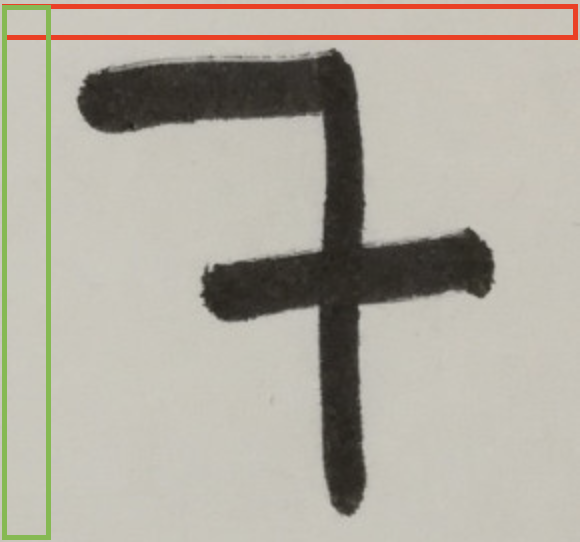

In [ ]:
# let's insert 200 fake images
# build 2 28x28 grid one for pixels X positions and one for pixels Y positions --> np.mgrid
# you pass it the image format (28x28) as ranges 0:28, 0:28 and returns 2 28x28 matrix one with the X positions and the other with the Y positions

yy, xx = np.mgrid[0:28, 0:28]

# fix a random center inside the ranges 0-28
# compute distances to the center --> 28x28 matrix, 0 at the center distance_to_center[14,14] + it grows as you go away
xc = 14
yc = 14

distance_to_center = ((xx - xc)**2) + ((yy-yc)**2)

# fix sigma 
# turn that distance_to_center matrix into a Gaussian intensity image --> e**(- distance_to_center / 2*sigma**2)

sigma = 3
gaussian_blob = np.exp(- (distance_to_center) / (2*sigma**2))
print(gaussian_blob)



- this builds one synthetic blob image, we want let's say 200

Remember to
- normalize df because the blobs are normalized
- flatten/reshape the 28x28
- turn it into a df
- concatenate it to the original df (at the end)
- keep track of these synthetic images --> set label = 1

In [ ]:
df = df / 255

In [ ]:
xc = 14
yc = 14
sigma = 3
n_blobs = 200

blob_rows = []
yy, xx = np.mgrid[0:28, 0:28]
for _ in range(n_blobs):
    distance_to_center = ((xx - xc)**2) + ((yy-yc)**2)
    gaussian_blob = np.exp(- (distance_to_center) / (2*sigma**2))
    gaussian_blob = np.reshape(gaussian_blob, shape=(1,28*28))
    blob_rows.append(gaussian_blob)

blob_matrix = np.vstack(blob_rows)
blob_df = pd.DataFrame(blob_matrix, columns=df.columns)
df = pd.concat(objs=[df, blob_df], ignore_index=True)


In [ ]:
anomalous_blobs = df.iloc[-200:, :].values

some_anomalous_blobs_idx = np.random.choice(a=anomalous_blobs.shape[0], size=10)
some_anomalous_blobs = anomalous_blobs[some_anomalous_blobs_idx]

plt.figure(figsize=(12,12))
for plt_idx, blob in enumerate(some_anomalous_blobs):    
    blob = np.reshape(blob, shape=(28,28))
        
    plt.subplot(5,2,plt_idx+1)
    plt.imshow(X=blob, cmap='gray', vmin=0, vmax=1)
    plt.title(f'row / image {some_anomalous_blobs_idx[plt_idx]}')

plt.tight_layout()
plt.show()

In [ ]:
anomalies = np.zeros(shape=df.shape[0], dtype=int)

# df rows I directly modified adding heavy point anomalies (pepper and salt)
pepper_salt_row_idx = np.random.choice(a=df.shape[0], size=(500), replace=False)
anomalies[pepper_salt_row_idx] = 1

# df rows I did not modify but which the autoencoder reconstructed poorly (high MSE) so I flagged them as anomalies --> noisy or low-quality digits
worst_idxs = np.argsort(mean_sum_sqr_error)[::-1][:1800]
anomalies[worst_idxs] = 1

# synthetic df rows I added that are collective anomalies
blobs_idx = df.iloc[-200:, :].index
anomalies[blobs_idx] = 1

df['label'] = anomalies
display(df)
display(df['label'].value_counts())


----

# NOW WE CAN START THE LAB PORCO DIO CHE FATICA

# 2. Apply at least three anomaly-detection methods among:
1. Local Outlier Factor (LOF),  
2. Isolation Forest,  
3. One-Class SVM,  
4. K-Means,  
5. Autoencoder reconstruction error.  

Each method must produce an anomaly score:
- LOF: the negative local density score (larger = more anomalous),
- Isolation Forest: the negative of score_samples (shorter paths → larger score),
- One-Class SVM: the negative of the decision function, K-Means the distance to the nearest centroid,
- Autoencoder: the reconstruction error.

Ensure all scores follow a consistent convention (higher = more anomalous).

In [ ]:
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam


# LOF
- Local Outlier Factor LOF
    - basically identical to DBSCAN, it's density based
    - uses n_neighbours and **contamination**: expected fraction of outliers in the data --> if in doubt go for 0.05
    - returns labels: if labels == 1 the point is fine, if it's ==-1 than it's an outlier
    - LOF gives each point a “how weird are you” score --> **negative_outlier_factor_**

- for this ex use a basic version fo each model and store the **POSITIVE** anomaly score of each model, ignore the hyperparameters

In [ ]:
data_df = df.loc[:, '1x1':'28x28']
labels_df = df['label']
df.shape

- we know the anomalies are 2490 --> contamination = The amount of contamination of the data set, i.e. the proportion of outliers in the data set --> 2490 / 60200 = 0.04136
- we can try different n_neighbours get the sorted negative_outlier_factor_ and plot them and pick the one with the cleanest elbow
    - this plot is garbage, you can't say anything about this --> find another way
    - just pick n_neighbours = 50, contamination = 0.04136 and predict changing the sign of the negative_outlier_factor_

> **NOTE**:  
- LOF computes distances, euclidean distances
- These distances becomes less informative with high dimensionality --> consider a PCA

In [ ]:
# this is just an example of how you set it up
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.0414, n_jobs=-1)
anomaly_flags = lof.fit_predict(data_df.values)

normal_data = data_df.values[anomaly_flags==1, :]
anomaly_data = data_df.values[anomaly_flags==-1, :]
print(anomaly_data.shape)

data_weirdness = - lof.negative_outlier_factor_
df['LOF_anomaly_score'] = data_weirdness

display(df)

In [ ]:
# inspect anomalous data
anomaly_data_sample_idx = np.random.choice(anomaly_data.shape[0], size=5, replace=False)
anomaly_data_sample = anomaly_data[anomaly_data_sample_idx]

plt.figure(figsize=(10,10))
for plt_idx, anomaly in enumerate(anomaly_data_sample):
    anomaly = np.reshape(anomaly, shape=(28,28))

    plt.subplot(3,2,plt_idx+1)
    plt.imshow(X=anomaly, cmap='gray', vmin=0, vmax=1)
    plt.title('anomalous data')

plt.tight_layout()
plt.show()

# inspect normal data too
normal_data_sample_idx = np.random.choice(normal_data.shape[0], size=5, replace=False)
normal_data_sample = normal_data[normal_data_sample_idx]

plt.figure(figsize=(10,10))
for plt_idx, normal in enumerate(normal_data_sample):
    normal = np.reshape(normal, shape=(28,28))

    plt.subplot(3,2,plt_idx+1)
    plt.imshow(X=normal, cmap='gray', vmin=0, vmax=1)
    plt.title('normal data')

plt.tight_layout()
plt.show()

# inspect data weirdness too
    # anomalies have big score (>1) --> the sort is ascending by default, so reverse it and the anomalies are at the beginning
data_weirdness = np.sort(data_weirdness)[::-1]
plt.figure(figsize=(8,6))
plt.plot(data_weirdness[:3000])         # don't all points, it's clearer if you plot only sum
# plt.axhline(y=1)
plt.xlabel('sorted images')
plt.ylabel('data weirdness')
plt.title('higher score = anomaly')


- everything is normal in the last plot:
    - normal points = score ≈ 1
    - anomalies = score > 1
    - but wtf why are they so high?
        - they happen when LOF’s “local density” math becomes degenerate. LOF decides if a point is weird by comparing how crowded it is vs how crowded its neighbors are. It estimates “crowdedness” using distances to the k nearest neighbors. Ok. BUT, many points are identical (or extremely close), then distance to neighbors becomes 0 (or almost 0) --> If distances are ~0, densities become extreme (think “divide by ~0” situations), so the ratio can become huge.
        - OR they can happen with genuinely isolated in pixel space, so LOF assigns very large outlier scores. This is “expected huge”.

In [ ]:
# explicitly look at anomalies scores in the DF
salt_and_pepper_scores = df.iloc[pepper_salt_row_idx, -1:]
print(f"The salt an peppers anomalies are: {len(pepper_salt_row_idx)}")
print("The recognised ones are")
display(salt_and_pepper_scores[salt_and_pepper_scores['LOF_anomaly_score'] >= 2], len(salt_and_pepper_scores[salt_and_pepper_scores['LOF_anomaly_score'] >= 2]))
# so the weird scores are because of salt and pepper anomalies :)

low_quality_scores = df.iloc[worst_idxs, -1:]
print(f"The low quality noise anomalies are {len(low_quality_scores)}")
print("The recognised ones are")
display(low_quality_scores[low_quality_scores['LOF_anomaly_score'] >= 2], len(low_quality_scores[low_quality_scores['LOF_anomaly_score'] >= 2]))
# and the low quality anomalies

collective_anomalies_scores = df.iloc[blobs_idx, -1:]
print(f"The collective anomalies are {len(blobs_idx)}")
print("The recognised ones are")
display(collective_anomalies_scores[collective_anomalies_scores['LOF_anomaly_score'] >= 2], len(collective_anomalies_scores[collective_anomalies_scores['LOF_anomaly_score'] >= 2]))

- the model didn't really spot the anomalies ...
    - for example the model did not flag the collective anomalies as anomalies
    - as we can see from the imgshow of the anonimous data and the normal data it did not really do a good job
    - as we can see from the line plot of the data weirdness the model recognised 200 anomalous values (probably the salt and pepper ones) and that's it, we forced it to include the remaining to reach 2490
    - as we can see from th explicit inspection it recognises:
        - 4/500 salt and pepper anomalies
        - 18/1800 noise anomalies
        - 0/200 collective anomalies

---

# Isolation Forest
- it runs a lot of tree classifier in parallel which randomly select a feature and then randomly slect a split value --> normal data still stays in groups even after random splits, while anomalies get lonly fast = shorter tree length 
- it's like a normal random forest but with also **contamination**
- it returns labels, if label == 1 the point is fine, if label == -1 it's an anomaly

In [ ]:
data_df = df.loc[:, '1x1':'28x28']
labels_df = df['label']

In [ ]:
IF = IsolationForest(n_estimators=100, contamination=0.0414, bootstrap=True, n_jobs=-1, random_state=42)
anomalies_flags = IF.fit_predict(data_df.values)
print(anomalies_flags, anomalies_flags.shape)

normal = data_df.values[anomalies_flags==1, :]
anomalous_data = data_df.values[anomalies_flags==-1, :]

data_weirdness = - IF.score_samples(data_df.values)
print(data_weirdness)

In [ ]:
# inspect anomalous data through plot
anomalous_data_sample_idx = np.random.choice(anomalous_data.shape[0], size=10)
anomalous_data_sample = anomalous_data[anomalous_data_sample_idx]

plt.figure(figsize=(12,12))
for plt_idx, anomalous_data_plt in enumerate(anomalous_data_sample):
    anomalous_data_plt = np.reshape(anomalous_data_plt, shape=(28,28))
    
    plt.subplot(5,2,plt_idx+1)
    plt.imshow(X=anomalous_data_plt, cmap='gray', vmin=0, vmax=1)

plt.tight_layout()
plt.show()

In [ ]:
# plot sorted scores to see if they're high even around 2490 or if they drop and the model was forced to flag some points as anomalies
sorted_data_weirdness = np.sort(data_weirdness)[::-1]   # big values first

print(sorted_data_weirdness[:3000])

plt.figure(figsize=(8,6))
plt.plot(sorted_data_weirdness[:60000])
plt.axvline(x=2490)
plt.xlabel('sorted images')
plt.ylabel('anomaly score')
plt.title('anomaly score plot isolation forest')
plt.show()

# build new column with scores
df['IF_anomaly_score'] = data_weirdness

- we can't say much actually, as the normal values are not around a specific value, we just know the anomalous values have higher score ... that's it.
- we can say it definetly got some points, maybe even too many :)

In [ ]:
# manually checking the scores for the actual anomalies --> use 0.50 as a threshold

salt_and_pepper_scores = df.iloc[pepper_salt_row_idx, -1:]
print(f"The salt an peppers anomalies are: {len(pepper_salt_row_idx)}")
print("The recognised ones are")
display(salt_and_pepper_scores[salt_and_pepper_scores['IF_anomaly_score'] >= 0.5].head(5), len(salt_and_pepper_scores[salt_and_pepper_scores['IF_anomaly_score'] >= 0.5]))

low_quality_scores = df.iloc[worst_idxs, -1:]
print(f"The low quality noise anomalies are {len(low_quality_scores)}")
print("The recognised ones are")
display(low_quality_scores[low_quality_scores['IF_anomaly_score'] >= 0.5].head(5), len(low_quality_scores[low_quality_scores['IF_anomaly_score'] >= 0.5]))

collective_anomalies_scores = df.iloc[blobs_idx, -1:]
print(f"The collective anomalies are {len(blobs_idx)}")
print("The recognised ones are")
display(collective_anomalies_scores[collective_anomalies_scores['IF_anomaly_score'] >= 0.5].head(5), len(collective_anomalies_scores[collective_anomalies_scores['IF_anomaly_score'] >= 0.5]))


- these are pretty ok scores!
    - 57/500 point anomalies found
    - 774/1800 noise anomalies found
    - 200/200 collctive anomalies found!

---

# One-Class SVM
- Imagine you have mostly normal points.
- One-Class SVM draws a boundary around where the normal points live.
- Points inside the boundary → normal.
- Points outside → anomalies.
- With an RBF kernel it can draw a “wiggly” boundary, not just a straight line.

- do the fit_predict with data, return labels --> 1 normal data, -1 anomalies
- get the score with score_samples()

### Hyperparameters
#### 1) kernel (shape of the boundary)  
- rbf (most common): curved boundary, good default.
- linear: flat boundary; usually too weak for complex data.
- poly, sigmoid: less common; can be finicky.

#### 2) nu (ν) — the “how many outliers do I allow?”
Range: (0, 1]. Meaning:  
- roughly an upper bound on the fraction of training points treated as outliers
- and a lower bound on the fraction of support vectors

Dumb interpretation:  
- small nu (e.g. 0.01): “I believe almost everything is normal” → tight outlier budget.
- larger nu (e.g. 0.05, 0.1): “I expect more anomalies/noise” → boundary allows more points to be outside.

#### 3) gamma (RBF only) — how “wiggly” the boundary is  
Controls how local the RBF influence is:
- small gamma: very smooth, broad boundary (can underfit)
- large gamma: very wiggly boundary hugging points (can overfit, label tons of outliers)

> NOTE:  
- it needs standardization
- usually PCA

In [ ]:
data_df = df.loc[:, '1x1':'28x28']
labels_df = df['label']

In [ ]:
OSVM = OneClassSVM(kernel='rbf', nu=0.04, gamma='scale')
anomalies_flags = OSVM.fit_predict(data_df.values)
# data_weirdness = - OSVM.score_samples(data_df.values)
data_weirdness = -OSVM.decision_function(data_df.values)    # anomalies are positive, normal data is negative

normal_data = data_df.values[anomalies_flags==1, :]
anomalous_data = data_df.values[anomalies_flags==-1, :]

print(anomalous_data.shape)

- damn that's slow

In [ ]:
# plot anomalous data
subset_anomalous_data_idx = np.random.choice(anomalous_data.shape[0], size=10)
subset_anomalous_data = anomalous_data[subset_anomalous_data_idx]

plt.figure(figsize=(12,12))
for plt_idx, anomalous_data_plt in enumerate(subset_anomalous_data):
    anomalous_data_plt = np.reshape(anomalous_data_plt, shape=(28,28))

    plt.subplot(5,2,plt_idx+1)
    plt.imshow(X=anomalous_data_plt, cmap='gray', vmin=0, vmax=1)

plt.tight_layout()    
plt.show()


In [ ]:
# plot sorted scores
sorted_data_weirdness = np.sort(data_weirdness)[::-1]
plt.figure(figsize=(8,6))
plt.plot(sorted_data_weirdness[:3000])
plt.axvline(x=2490, c='green', alpha = 0.1)
plt.axhline(y=0, c='red', alpha = 0.1)
plt.xlabel('sorted images')
plt.ylabel('anomaly score')
plt.show()

- damn, seems kinda promising

In [ ]:
# add new column to df with the scores
df['OSVM_anomaly_score'] = data_weirdness

# manually checking the scores for the actual anomalies --> use 0.50 as a threshold
salt_and_pepper_scores = df.iloc[pepper_salt_row_idx, -1:]
print(f"The salt an peppers anomalies are: {len(pepper_salt_row_idx)}")
print("The recognised ones are")
display(salt_and_pepper_scores[salt_and_pepper_scores['OSVM_anomaly_score'] > 0].head(5), len(salt_and_pepper_scores[salt_and_pepper_scores['OSVM_anomaly_score'] > 0]))

low_quality_scores = df.iloc[worst_idxs, -1:]
print(f"The low quality noise anomalies are {len(low_quality_scores)}")
print("The recognised ones are")
display(low_quality_scores[low_quality_scores['OSVM_anomaly_score'] > 0].head(5), len(low_quality_scores[low_quality_scores['OSVM_anomaly_score'] > 0]))

collective_anomalies_scores = df.iloc[blobs_idx, -1:]
print(f"The collective anomalies are {len(blobs_idx)}")
print("The recognised ones are")
display(collective_anomalies_scores[collective_anomalies_scores['OSVM_anomaly_score'] > 0].head(5), len(collective_anomalies_scores[collective_anomalies_scores['OSVM_anomaly_score'] > 0]))


- meh scores:
    - 18/500 point anomalies
    - 437/1800 noise anomalies
    - 0/200 group anomalies

---

# K-Means

- KMeans:
    - for each point compute distance to closest centroids --> .transform(X).min(axis=1)
    - sort the distances
    - plot the sorted distances --> on the left points closer to the centroids they belong to, on the right points further away from the centroids they belong to = anomalies
    - look for an elbow --> figure out the % of anomalies and compute the number of anomalies N
    - from the sorted distances save the last N distances = anomalies
    - in the plot flag the points having these distances as anomalies


In [ ]:
data_df = df.loc[:, '1x1':'28x28']
labels_df = df['label']

In [ ]:
# io detesto quel ratto del professore, butta sti valori a cazzo di cane, no spiegazione, no logica, nulla
kmeans = KMeans(n_clusters=10, n_init=12, random_state=42)
kmeans.fit(data_df.values)
distance_closest_centroid = kmeans.transform(data_df.values).min(axis=1)


In [ ]:
sorted_distance_closest_centroid = np.sort(distance_closest_centroid)[::-1]
plt.figure(figsize=(8,6))
plt.plot(sorted_distance_closest_centroid[:6000])
plt.axvline(x=2490, c='red', alpha=0.1)
plt.ylabel('distance to closest centroid')
plt.xlabel('sorted images')
plt.show()

In [ ]:
# build new column with score
df['KM_anomaly_score'] = distance_closest_centroid

# manually checking the scores for the actual anomalies --> use 8 as a threshold
salt_and_pepper_scores = df.iloc[pepper_salt_row_idx, -1:]
print(f"The salt an peppers anomalies are: {len(pepper_salt_row_idx)}")
print("The recognised ones are")
display(salt_and_pepper_scores[salt_and_pepper_scores['KM_anomaly_score'] > 8].head(5), len(salt_and_pepper_scores[salt_and_pepper_scores['KM_anomaly_score'] > 8]))

low_quality_scores = df.iloc[worst_idxs, -1:]
print(f"The low quality noise anomalies are {len(low_quality_scores)}")
print("The recognised ones are")
display(low_quality_scores[low_quality_scores['KM_anomaly_score'] > 8].head(5), len(low_quality_scores[low_quality_scores['KM_anomaly_score'] > 8]))

collective_anomalies_scores = df.iloc[blobs_idx, -1:]
print(f"The collective anomalies are {len(blobs_idx)}")
print("The recognised ones are")
display(collective_anomalies_scores[collective_anomalies_scores['KM_anomaly_score'] > 8].head(5), len(collective_anomalies_scores[collective_anomalies_scores['KM_anomaly_score'] > 8]))


- again, meh performance:
    - 17/500 point anomalies
    - 635/1800 noise anomalies
    - 0/200 collective anomalies

# DBSCAN
- DBSCAN:
    - already flags outliers / noise / anomalies as lable = -1
    - just plot as usual

- tune DBSCAN: plot distance to K-th neigbour, with K = min_samples = [3,5,10,15]

In [ ]:
data_df = df.loc[:, '1x1':'28x28']
labels_df = df['label']

In [ ]:
# # distance matrix (60200 x 60200)
# distance_matrix = np.zeros(shape=(data_df.shape[0],data_df.shape[0]))
# for fixed_idx in range(len(data_df)):
#     fixed_point = data_df.values[fixed_idx]
#     sqr_dist = (data_df.values - fixed_point)**2
#     sum_sqr_dist = np.sum(sqr_dist, axis=1)
#     distance = sum_sqr_dist**0.5
#     distance_matrix[fixed_idx] = distance

# OTHER QUICKER WAY
# compute distance matrix but only from each point to its 15th neighbour, included all the previous neighbours
k = 15
n_n = NearestNeighbors(n_neighbors=k+1, metric='euclidean', n_jobs=-1)  # +1 because the first neighbor is itself
n_n.fit(data_df.values)

distances, indices = n_n.kneighbors(data_df.values)           # distances shape: (N, k+1)

# plot distances for different number of neighbours
plt.figure(figsize=(12,12))
min_samples = [3,5,10,15]
for plt_idx, m in enumerate(min_samples):
    distance_k_neighbour = distances[:, m]
    sorted_distance_k_neighbour = np.sort(distance_k_neighbour)[::-1]
    
    plt.subplot(2,2, plt_idx+1)
    plt.plot(sorted_distance_k_neighbour)
    plt.axvline(x=2490, c='red', alpha=0.1)
    plt.axhline(y=6.6, c='green', alpha=0.1)
    plt.title(f"distance to {m} neighbours")
    plt.ylabel('distance')
    plt.xlabel('sorted images')

plt.tight_layout()
plt.show()

- try min_samples = 5 and eps = 6.6
- try min_samples = 3 and eps = 6.4-5
- try min_samples = 10 and eps = 7
- try min_samples = 15 and eps = 7.3

In [ ]:
dbscan = DBSCAN(eps=6.6, min_samples=5, n_jobs=-1)
anomalies_flags = dbscan.fit_predict(data_df.values)
anomalous_data = data_df.values[anomalies_flags==-1]

# plot it
sample_anomalous_data_idx = np.random.choice(anomalous_data.shape[0], size=10)
sample_anomalous_data = anomalous_data[sample_anomalous_data_idx]

plt.figure(figsize=(12,12))
for plt_idx, sample in enumerate(sample_anomalous_data):
    sample = np.reshape(sample, shape=(28,28))

    plt.subplot(5,2, plt_idx+1)
    plt.imshow(X=sample, cmap='gray', vmin=0 ,vmax=1)

plt.tight_layout()
plt.show()

---

# autoencoder
- it uses autoencoders:
    - you pass in input X with dimension N to an encoder, which reduces the dimension on the input compressing it to K << N
    - then a decoder tries to reconstruct the original input $\hat{X}$
    - build the model, the optimizer, the loss function, the tensor dataset, the dataloader and fix the number of epochs
    - train the model:
        - iterate on epochs
        - iterate on batches
        - zero the optimizer gradients
        - do the forward pass of the NN model passing the input X to compute the reconstructed input $\hat{X}$
        - compute loss function
        - take a step with otpimizer
    - then we compute reconstruction error RE for each feature:
        - if the input is a continuous number we use MSE
        - if the input is binary we use binary cross entropy
    - higher RE == anomalies

- build autoencoder

In [ ]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784,256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64,10),
            nn.ReLU()
            )

        self.decoder = nn.Sequential(
            nn.Linear(10,64),
            nn.ReLU(),
            nn.Linear(64,256),
            nn.ReLU(),
            nn.Linear(256,784),
            nn.Sigmoid()
            )
        

    def forward(self, x):
        encoded_input = self.encoder(x)
        reconstructed_input = self.decoder(encoded_input)
        return reconstructed_input

autoencoder = AutoEncoder()

- build:
    - tensor dataset (pass input data as tensor)
    - data loader (pass tensor dataset, create batches of dimension 250)
    - loss function (continuous values = MSEloss)
    - optimizer
    - n_epochs

In [ ]:
data_df = df.loc[:, '1x1':'28x28']
labels_df = df['label']

x = torch.Tensor(data_df.values)
x = x.float()
ds = TensorDataset(x)
dl = DataLoader(ds, batch_size=250, shuffle=True)
loss_function = nn.MSELoss()
optimizer = Adam(params=autoencoder.parameters(), lr=3e-4)
n_epochs = 10

In [ ]:
print(x_batch.min().item(), x_batch.max().item())

- training loop:
    - set the NN model to train
    - zero the optimizer gradient so it doesn't update based on the gradients of the previous runs 
    - forward pass to compute the reconstructed image 
    - compute loss with the loss function
    - loss.backward
    - update optimizer, take a step
    - store the loss --> get the loss 

In [ ]:
autoencoder.train()
for epoch in range(n_epochs):
    loss_all_batches = 0
    for (x_batch,) in dl:
        optimizer.zero_grad()
        reconstructed_input = autoencoder(x_batch)
        loss = loss_function(reconstructed_input, x_batch)
        loss.backward()
        optimizer.step()

        loss_all_batches += loss.item()
    
    loss_per_batch = loss_all_batches / len(dl)
    print(f"epoch {epoch} --> avg loss per batch: {loss_per_batch} ")
    

- after training actually feed the autoencoder the input:
    - set the model to evaluation + with torch.no_grad()
    - actually get the reconstructed input
    - manually compute the MSE: (reconstructed input - original input)**2 --> sum rows --> divide for the number of columns
    - sort the values and pick the values with highest MSE --> potenatial anomalies

In [ ]:
with torch.no_grad():
    x_reconstructed = autoencoder(x)

x_reconstructed = torch.Tensor.numpy(x_reconstructed)
x = torch.Tensor.numpy(x)

sqr_error = (x- x_reconstructed)**2
sum_sqr_error = np.sum(sqr_error, axis=1)
MSE = sum_sqr_error / x.shape[1]

In [ ]:
df['MSE_anomaly_score'] = MSE

sorted_MSE_idx = np.argsort(a=MSE)[::-1]
sorted_MSE = MSE[sorted_MSE_idx]
plt.figure(figsize=(8,6))
plt.plot(sorted_MSE)
plt.axvline(x=2490, c='red', alpha=0.1)
plt.axhline(y=0.05, c='green', alpha=0.1)
plt.xlabel('sorted images')
plt.ylabel('MSE score')
plt.title('autoencoder reconstruction MSE score')
plt.show()


In [ ]:
# manually checking the scores for the actual anomalies --> use 8 as a threshold
salt_and_pepper_scores = df.iloc[pepper_salt_row_idx, -1:]
print(f"The salt an peppers anomalies are: {len(pepper_salt_row_idx)}")
print("The recognised ones are")
display(salt_and_pepper_scores[salt_and_pepper_scores['MSE_anomaly_score'] > 0.05].head(5), len(salt_and_pepper_scores[salt_and_pepper_scores['MSE_anomaly_score'] > 0.05]))

low_quality_scores = df.iloc[worst_idxs, -1:]
print(f"The low quality noise anomalies are {len(low_quality_scores)}")
print("The recognised ones are")
display(low_quality_scores[low_quality_scores['MSE_anomaly_score'] > 0.05].head(5), len(low_quality_scores[low_quality_scores['MSE_anomaly_score'] > 0.05]))

collective_anomalies_scores = df.iloc[blobs_idx, -1:]
print(f"The collective anomalies are {len(blobs_idx)}")
print("The recognised ones are")
display(collective_anomalies_scores[collective_anomalies_scores['MSE_anomaly_score'] > 0.05].head(5), len(collective_anomalies_scores[collective_anomalies_scores['MSE_anomaly_score'] > 0.05]))


---

---

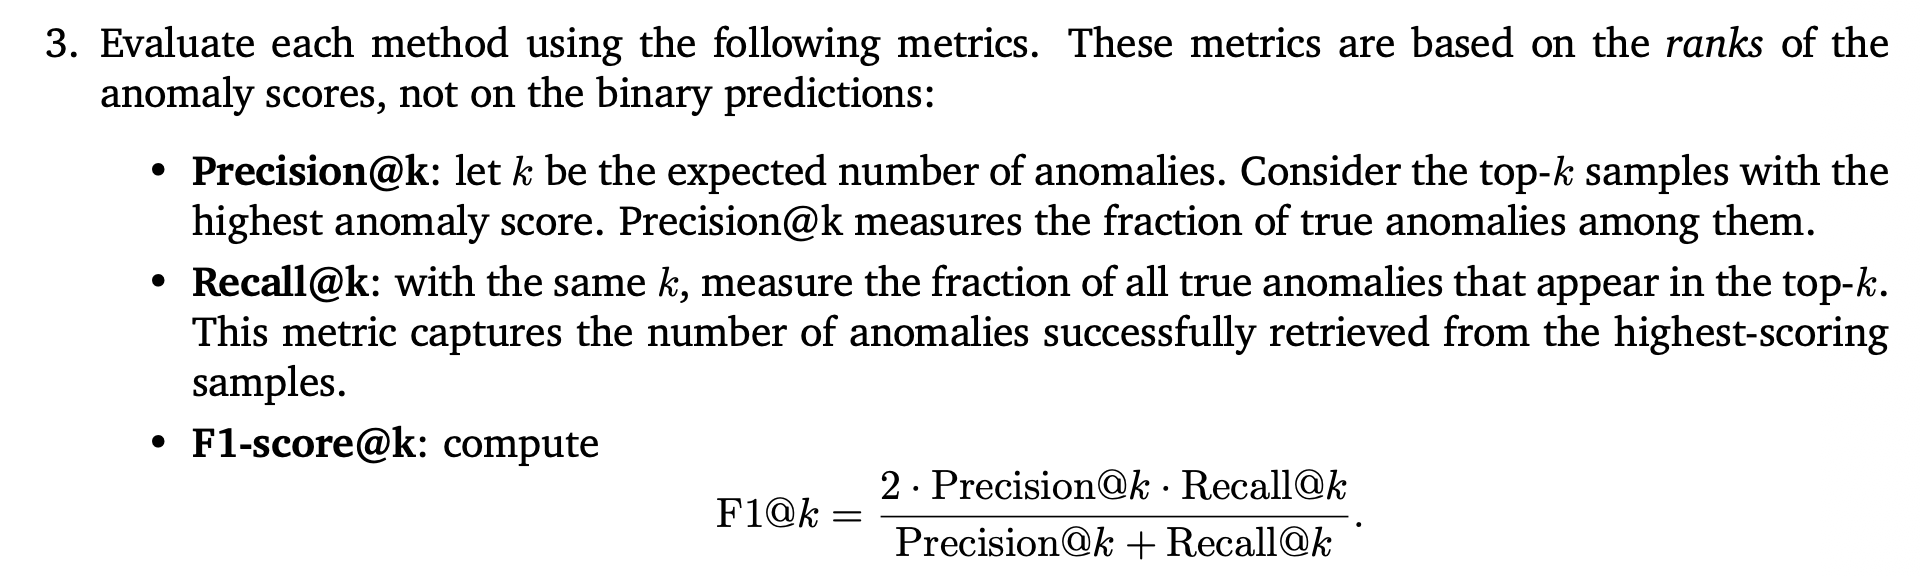

> # Precision@k:
- You have an anomaly score for every sample (higher = “more suspicious”).
- You sort all samples by score, from highest to lowest.
- You take the top k samples (the k most suspicious).
- Precision@k is: how many of those top k are truly anomalies (according to your ground-truth label), divided by k.

Formula:  
$\text{Precision@}k = \frac{\#\{\text{true anomalies in top }k\}}{k}$

Example:  
- You expect k=2500 anomalies total.
- Your model’s top 2500 scores contain 1800 true anomalies.
- Precision@2500 = 1800/2500 = 0.72.


> ### DO NOT USE K = TOTAL NUMBER OF ANOMALIES OTHERWISE YOU COMPUTE THE RECALL

In [ ]:
# number of anomalies
k = 2488

In [ ]:
cols = ['LOF_anomaly_score','IF_anomaly_score', 'OSVM_anomaly_score', 'KM_anomaly_score','MSE_anomaly_score']

blobs_idx = np.array(blobs_idx)
pepper_salt_row_idx = np.array(pepper_salt_row_idx)
anomalies_idx = np.hstack(tup=[pepper_salt_row_idx, blobs_idx, worst_idxs]) # concatenates also duplicate stuff
anomalies_idx = np.unique(anomalies_idx)

# print(anomalies_idx.shape)    --> ops I thought they were 2490 :)

for col in cols:
    sorted_k_values = df[col].sort_values(ascending=False)[:k]
    sorted_k_values_idx = sorted_k_values.index
    found_anomalies_count = sorted_k_values_idx.isin(anomalies_idx).sum()
    print(f"{col} --> precision@{k}: {found_anomalies_count/k}")


---

> # Recall@k
- Total true anomalies in the dataset: 2488 --> so k = 2488.
- You sort all samples by anomaly score (highest first) and take the top 2488 samples.
- Suppose inside those top 2488, you find 1800 samples that are truly anomalies.

> ### ALWAYS DIVIDES FOR THE TOTAL NUMBER OF ANOMALIES, EVEN IF YOU PICK K < 2488

Then:  
$Recall@2488 = \frac{1800}{2488} = 0.724$

Meaning: “Looking only at the top-k most suspicious samples, you recovered about 72% of all anomalies in the dataset.”  
> Note: when k equals the total number of anomalies, Recall@k = Precision@k (both are $\text{TP} / k$).

- I will not do the same thing again --> so let's try with K = 1500

In [ ]:
k = 1500
for col in cols:
    sorted_k_scores = df[col].sort_values(ascending=False)[:k]
    sorted_k_scores_idx = sorted_k_scores.index
    found_anomalies_count = sorted_k_scores_idx.isin(anomalies_idx).sum()
    print(f"{col} --> Recall@{k} : {found_anomalies_count / k}")


---

# EXAMPLE
- Let total true anomalies be A = 2488. Pick k = 1500.  
- Sort by anomaly score (highest first) and take the top 1500 samples.
- Let TP = how many of those 1500 are truly anomalies.

- Suppose in the top 1500 you find TP = 900 true anomalies.

> Precision@1500  
“How pure are my top 1500 picks?”  
$\text{Precision@1500}=\frac{TP}{1500}=\frac{900}{1500}=0.60$  

> Recall@1500  
“How many of all anomalies did I recover?”  
$\text{Recall@1500}=\frac{TP}{A}=\frac{900}{2488}\approx 0.362$  

> F1@1500  
Balance between the two:  
$F1@1500=\frac{2PR}{P+R} =\frac{2\cdot 0.60 \cdot 0.362}{0.60+0.362} =\frac{0.4344}{0.962}\approx 0.452$

> # F1-score@k
$F1@k=\frac{2\cdot \text{Precision@}k \cdot \text{Recall@}k}{\text{Precision@}k+\text{Recall@}k}$  

Same here, if we pick k = tot number anomalies, then precision@k = recall@k = p, then:  
$F1@k=\frac{2p\cdot p}{p+p}=\frac{2p^2}{2p}=p$  
The F1@k is the same too  
> AVOID USING K = TOT NUMBER ANOMALIES FOR F1@K  

Try it out using k = 1500

In [ ]:
cols = ['LOF_anomaly_score','IF_anomaly_score', 'OSVM_anomaly_score', 'KM_anomaly_score','MSE_anomaly_score']

blobs_idx = np.array(blobs_idx)
pepper_salt_row_idx = np.array(pepper_salt_row_idx)
anomalies_idx = np.hstack(tup=[pepper_salt_row_idx, blobs_idx, worst_idxs]) # concatenates also duplicate stuff
anomalies_idx = np.unique(anomalies_idx)

tot_anomalies = 2488
k = 1500

for col in cols:
    sorted_k_values = df[col].sort_values(ascending=False)[:k]
    sorted_k_values_idx = sorted_k_values.index
    found_anomalies_count = sorted_k_values_idx.isin(anomalies_idx).sum()
    
    precision = found_anomalies_count/k
    recall = found_anomalies_count/tot_anomalies
    F1 = (2*precision*recall) / (precision+recall)
    print(f"{col} --> precision@{k}: {precision}")
    print(f"{col} --> recall@{k}: {recall}")
    print(f"{col} --> F1@{k}: {F1}")
    print()
    
